In [2]:
import json
from matplotlib.colors import ListedColormap
import sys
import os
from pathlib import Path

# Add the project root (or current file directory)
sys.path.append(str(Path(os.getcwd()).resolve().parent))

from touch_detection_alg.pipeline import compute_depth

IDX = 0
GREEN = ListedColormap([[0, 0, 0, 0], [0, 1, 0, 1]])
RED = ListedColormap([[0, 0, 0, 0], [1, 0, 0, 1]])
YELLOW = ListedColormap([[0, 0, 0, 0], [1, 1, 0, 1]])
BLUE = ListedColormap([[0, 0, 0, 0], [0, 0, 1, 1]])

In [3]:
json_file = "/home/scur0813/FOMO/touch_from_segmentation/data/greatest_hits/annotations/train.json"

{
    "image_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000766.jpg",
    "stick_mask_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000766_stick.png",
    "object_mask_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000766_object.png",
    "target_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/greatest_hits/masks/2015-02-16-17-54-47_denoised/frame_000766_touch.png",
    "type": "touch",
    "video_id": "2015-02-16-17-54-47_denoised",
    "material": ""
}


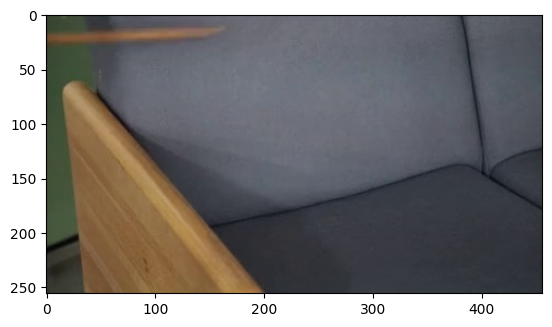

In [4]:
IDX = 400
with open(json_file, 'r') as file:
    gh_data = json.load(file)
    image_entry = gh_data[IDX]

print(json.dumps(image_entry, indent=4))
import matplotlib.pyplot as plt
plt.imshow(plt.imread(image_entry["image_path"]))
# good: 73, 30, 148, 175, 222, 275, 300, 340, 400

In [5]:
import matplotlib.pyplot as plt
CMAP = ListedColormap([0,0,0,0],[0,1,0,1])
def save_hits_images(idx, data):
    image_entry = data[idx]
    image = image_entry["image_path"]
    stick_mask = image_entry["stick_mask_path"]
    obj_mask = image_entry["object_mask_path"]
    touch_mask = image_entry["target_path"]
    
    # original image 
    plt.imshow(plt.imread(image))
    plt.axis('off')
    plt.savefig(f"{idx}_gh_original.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    # image with masks
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(stick_mask), alpha=0.5, cmap=YELLOW)
    plt.imshow(plt.imread(obj_mask), alpha=0.5, cmap=BLUE)
    plt.axis('off')
    plt.savefig(f"{idx}_gh_masks.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    
    # impage with POT
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(touch_mask), alpha=0.5, cmap=GREEN)
    plt.axis('off')
    plt.savefig(f"{idx}_gh_touch.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    depth = compute_depth(plt.imread(image), guided_filter=False)
    plt.imshow(depth, cmap = 'inferno')
    plt.axis('off')
    plt.savefig(f"{idx}_gh_depth.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    
# 400 shiit
# 602/702 good
# save_hits_images(702, gh_data)


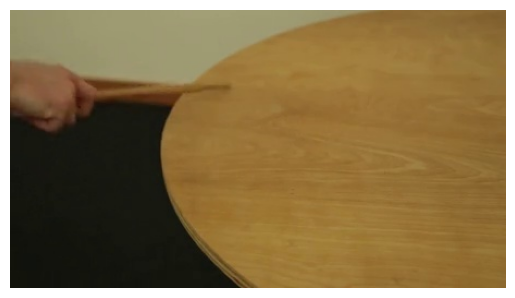

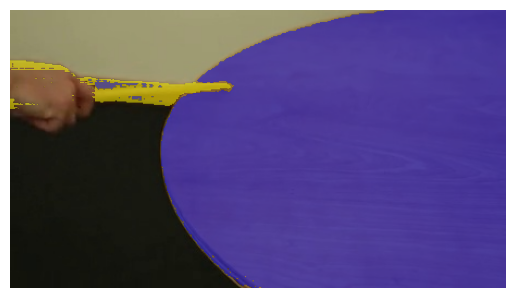

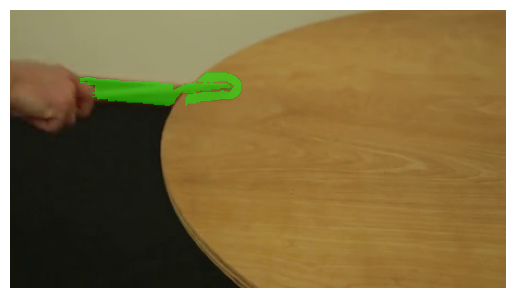

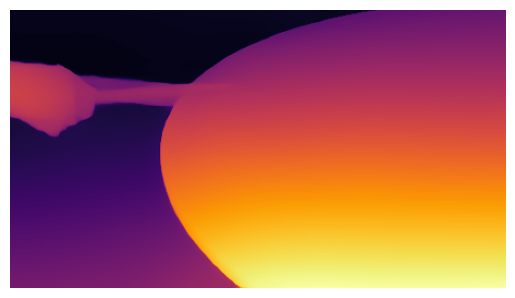

In [7]:
idx_list = [800]
for i in idx_list:
    save_hits_images(i, gh_data)

{
    "image_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/epic_kitchen/frames/P01_03/P01_03_frame_0000001529.jpg",
    "hand_mask_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/epic_kitchen/masks/P01_03/P01_03_frame_0000001529_p0_hand.png",
    "object_mask_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/epic_kitchen/masks/P01_03/P01_03_frame_0000001529_p0_object.png",
    "target_path": "/gpfs/home4/scur0813/FOMO/touch_from_segmentation/data/epic_kitchen/masks/P01_03/P01_03_frame_0000001529_p0_touch.png",
    "type": "touch",
    "video_id": "P01_03",
    "object_name": "soy milk"
}


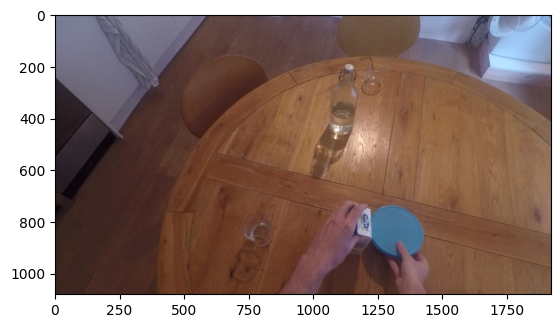

In [ ]:
# good 70, 71, 72,73
IDX =73
epic_kitchen_file = "/home/scur0813/FOMO/touch_from_segmentation/data/epic_kitchen/annotations/train.json"
with open(epic_kitchen_file, 'r') as file:
    epic_kitchen_data = json.load(file)
    epic_kitchen_image_entry = epic_kitchen_data[IDX]

print(json.dumps(epic_kitchen_image_entry, indent=4))
import matplotlib.pyplot as plt
plt.imshow(plt.imread(epic_kitchen_image_entry["image_path"]))

In [107]:
def save_epic_kitchen_images(idx, data, dilated: bool = False):
    image_entry = data[idx]
    image = image_entry["image_path"]
    hand_mask = image_entry["hand_mask_path"]
    obj_mask = image_entry["object_mask_path"]
    touch_mask = image_entry["target_path"]
    if dilated:
        touch_mask = touch_mask.replace(".png", "_dilated_r40.png")
    
    
    # original image 
    plt.imshow(plt.imread(image))
    plt.axis('off')
    plt.savefig(f"{idx}_ep_original.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    # image with masks
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(hand_mask), alpha=0.5, cmap=YELLOW)
    plt.imshow(plt.imread(obj_mask), alpha=0.5, cmap=BLUE)
    plt.axis('off')
    plt.savefig(f"{idx}_ep_masks.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    # impage with POT
    plt.imshow(plt.imread(image))
    plt.imshow(plt.imread(touch_mask), alpha=0.5, cmap=GREEN)
    plt.axis('off')
    plt.savefig(f"{idx}_ep_touch.png",bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    
    depth = compute_depth(plt.imread(image), guided_filter=False)
    plt.imshow(depth, cmap = 'inferno')
    plt.axis('off')
    plt.savefig(f"{idx}_ep_depth.png", bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    

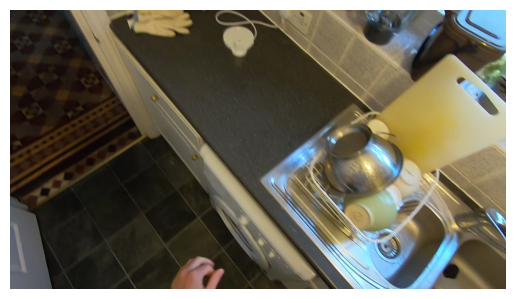

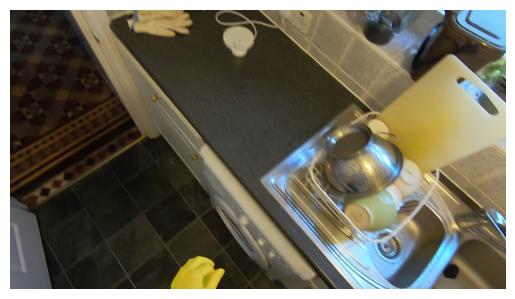

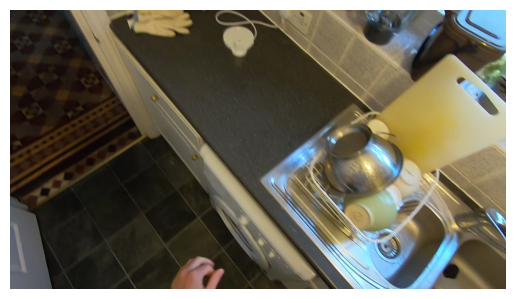

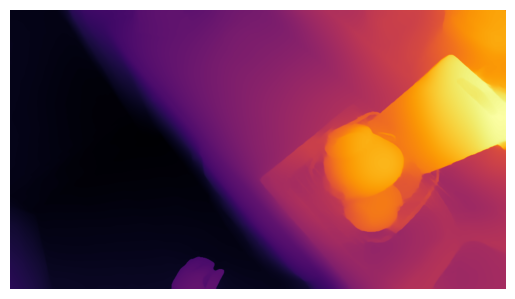

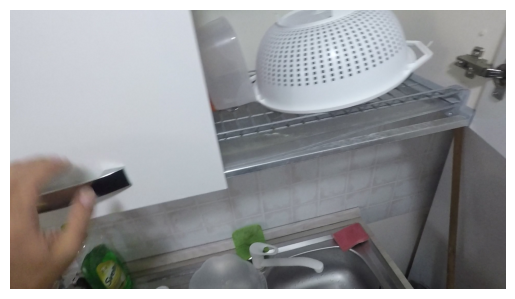

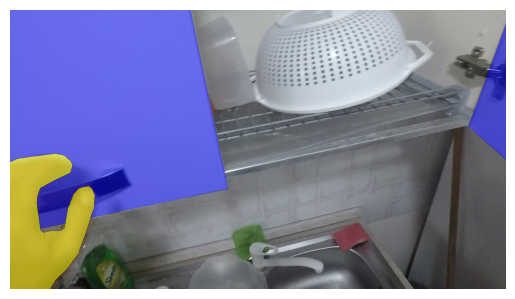

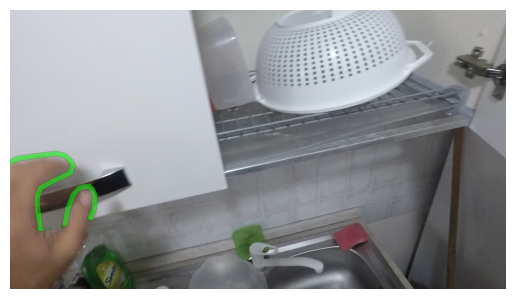

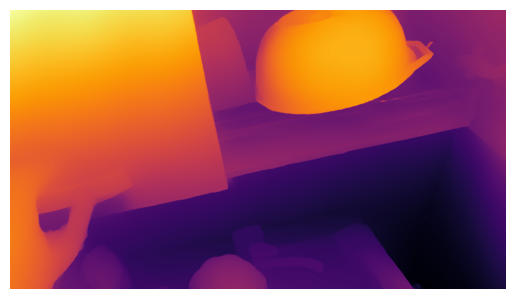

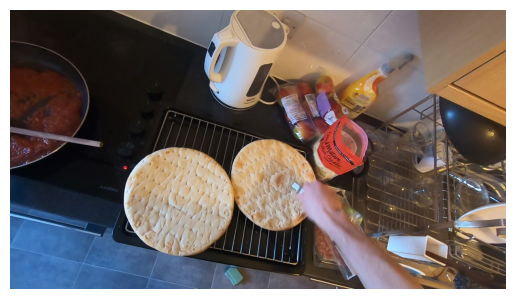

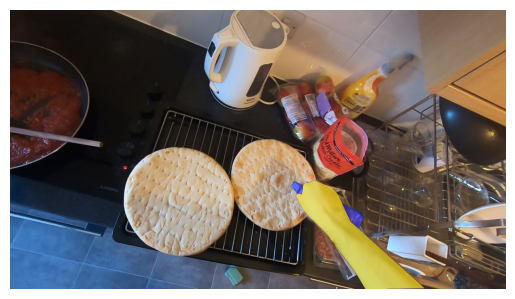

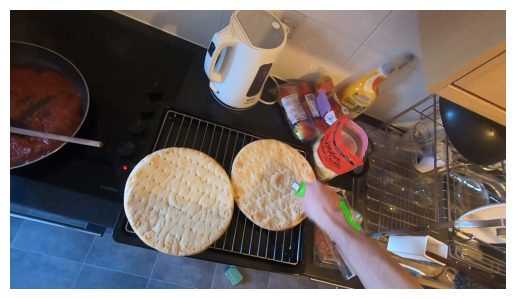

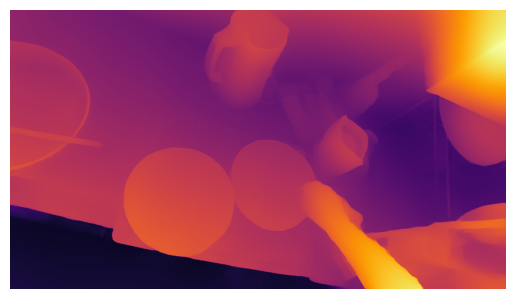

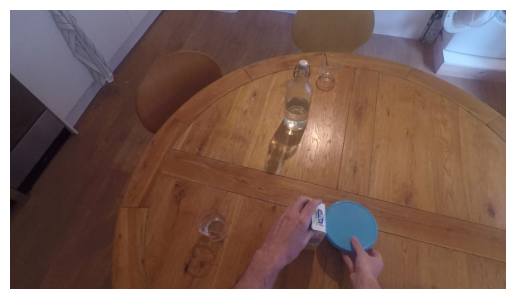

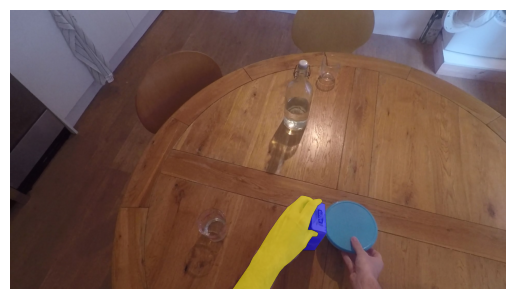

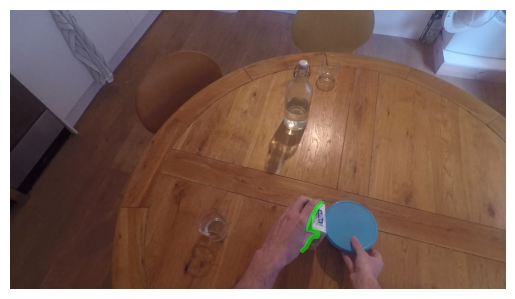

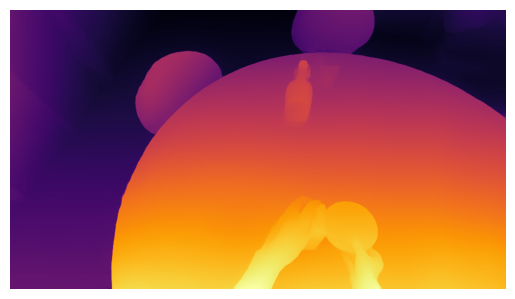

In [154]:
# save_epic_kitchen_images(3, data = epic_kitchen_data, dilated=False)

# good for touch: 33, 56, 96
# good for no touch: 99, 2873

idx_list = [70, 71, 72,73]
for i in idx_list:
    save_epic_kitchen_images(i, data = epic_kitchen_data, dilated=False)